In [ ]:
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from config import USERNAME

In [2]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [ ]:
ds = datasets.ImageFolder(f"/Users/{USERNAME}/myProjects/trash-classification/data/raw/original", transform)


['battery',
 'biological',
 'cardboard',
 'glass',
 'metal',
 'paper',
 'plastic',
 'trash']

In [7]:
for i, class_name in enumerate(ds.classes):
    count = ds.targets.count(i)
    print(f"{class_name} : {count}")

battery : 756
biological : 699
cardboard : 1411
glass : 1736
metal : 930
paper : 1336
plastic : 1597
trash : 453


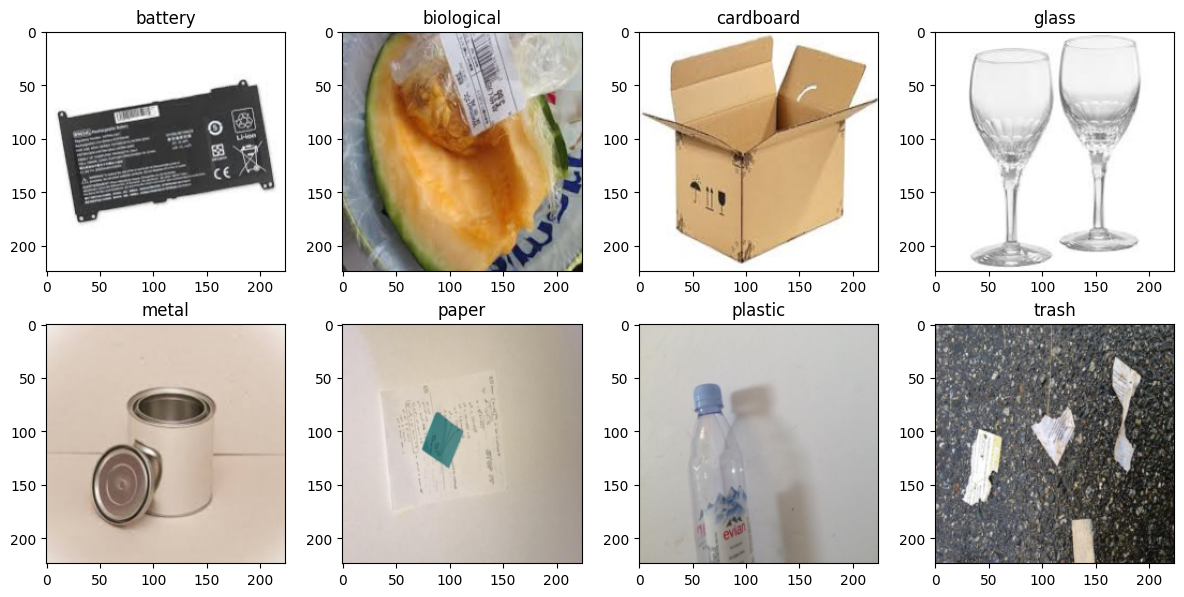

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i, class_name in enumerate(ds.classes):
    img_idx = ds.targets.index(i)
    image = ds[img_idx][0].permute(1, 2, 0)
    axes[i].imshow(image)
    axes[i].set_title(class_name)

plt.tight_layout()
plt.show()

In [16]:
train_ds, val_ds, test_ds = torch.utils.data.random_split(ds, (7134, 892, 892))


In [ ]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)